In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

In [20]:
df=pd.read_csv(
    "data/SMSSpamCollection.csv",sep="\t",header=None,
    names=["label","messages"]
)

In [21]:
df.head()

,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
print("Null value: \n",df.isnull().sum())
print("Duplicated values: \n",df.duplicated().sum())

Null value: 
 label       0
messages    0
dtype: int64
Duplicated values: 
 403


In [23]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


label
ham     4516
spam     653
Name: count, dtype: int64


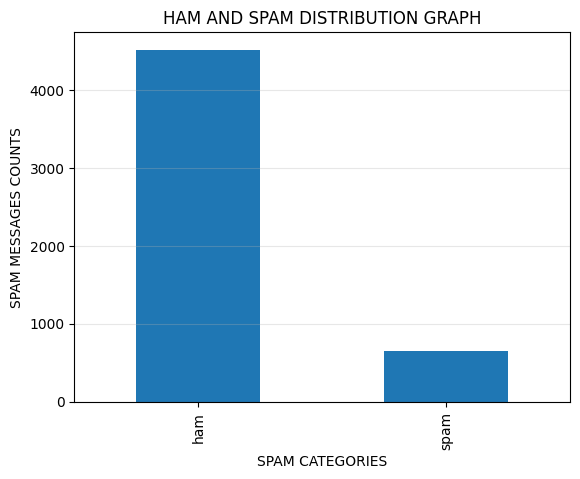

In [24]:
print(
    df["label"].value_counts()
)
df["label"].value_counts().plot(kind="bar")
plt.xlabel("SPAM CATEGORIES")
plt.ylabel("SPAM MESSAGES COUNTS")

plt.title("HAM AND SPAM DISTRIBUTION GRAPH")
plt.grid(alpha=0.3,axis="y")
plt.savefig("images/ham_spam_distribution_graph.png")

In [25]:
df.isna().sum()

label       0
messages    0
dtype: int64

In [26]:
df.dtypes

label       str
messages    str
dtype: object

In [32]:
X=df["messages"]
y=df["label"]

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,stratify=y,test_size=0.2
)

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer()

X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)


In [35]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 7680)
(1034, 7680)


In [37]:
from sklearn.naive_bayes import MultinomialNB

nb_model=MultinomialNB()

nb_model.fit(X_train_tfidf,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [40]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,classification_report

nb_pred=nb_model.predict(X_test_tfidf)
print("MultinomialNB Model Accuracy: \n",
      accuracy_score(
          y_test,nb_pred
      ))
print("Confusion Matrix: \n",
      confusion_matrix(
          y_test,nb_pred
      ))
print("Classification Report: \n",
    classification_report(
        y_test,nb_pred
    )
      )


MultinomialNB Model Accuracy: 
 0.9526112185686654
Confusion Matrix: 
 [[903   0]
 [ 49  82]]
Classification Report: 
               precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       1.00      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.96      0.95      0.95      1034



In [41]:
from sklearn.linear_model import LogisticRegression

lr_model=LogisticRegression(
    max_iter=1000
)
lr_model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
lr_pred=lr_model.predict(X_test_tfidf)

print("Logistic Regression: \n",
    accuracy_score(
        y_test,lr_pred
    )
      )
print("Confusion Matrix: \n",confusion_matrix(y_test,lr_pred))
print("Classification Report: \n",classification_report(y_test,lr_pred))

Logistic Regression: 
 0.9642166344294004
Confusion Matrix: 
 [[899   4]
 [ 33  98]]
Classification Report: 
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.96      0.75      0.84       131

    accuracy                           0.96      1034
   macro avg       0.96      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034



In [43]:
from sklearn.svm import LinearSVC

svm_model=LinearSVC()

svm_model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [44]:
svm_pred=svm_model.predict(X_test_tfidf)
print("SVM Model Accuracy: \n",accuracy_score(y_test,svm_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,svm_pred))
print("Classification Report: \n",classification_report(y_test,svm_pred))


SVM Model Accuracy: 
 0.9816247582205029
Confusion Matrix: 
 [[899   4]
 [ 15 116]]
Classification Report: 
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [46]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(
    estimator=svm_model,
    cv=5,
    X=X_train_tfidf,
    y=y_train,  
    scoring="accuracy"
)
print("Scores Per Folds: \n",scores)
print("Mean Accuracy: \n",scores.mean())

Scores Per Folds: 
 [0.97702539 0.97823458 0.97944377 0.98548972 0.97944377]
Mean Accuracy: 
 0.9799274486094316


In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid=GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)
grid.fit(X_train_tfidf,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are 

In [49]:
print("Best Score:  \n",grid.best_score_)
print("Best Parameter: \n",grid.best_params_)

Best Score:  
 0.9818621523579202
Best Parameter: 
 {'C': 100}


In [51]:
best_model=grid.best_estimator_

y_pred=best_model.predict(X_test_tfidf)
print(
    "Best Model Accuracy: \n",
    accuracy_score(
        y_test,y_pred
    )
)
print("Confusion Matrix: \n",confusion_matrix(
    y_test,y_pred
))
print("Classification Report: \n",classification_report(
    y_test,y_pred
))

Best Model Accuracy: 
 0.9816247582205029
Confusion Matrix: 
 [[897   6]
 [ 13 118]]
Classification Report: 
               precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.95      0.90      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [57]:
import joblib

best_svm = grid.best_estimator_

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(best_svm, "sms_spam_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [58]:
import os

print(os.path.exists("tfidf_vectorizer.pkl"))
print(os.path.exists("sms_spam_model.pkl"))

True
True


In [59]:
vectorizer=joblib.load("tfidf_vectorizer.pkl")
model=joblib.load("sms_spam_model.pkl")


In [60]:
message = ["Congratulations! You have won a free prize. Call now!"]

message_tfidf = vectorizer.transform(message)

prediction = model.predict(message_tfidf)

print("Prediction:", prediction[0])

Prediction: spam
